In [ ]:
# Importing packages

import pandas as pd
%load_ext rpy2.ipython
%load_ext autoreload
%autoreload 2

%matplotlib inline  
from matplotlib import rcParams
rcParams['figure.figsize'] = (16, 100)

import warnings
from rpy2.rinterface import RRuntimeWarning
warnings.filterwarnings("ignore") # Ignore all warnings
# warnings.filterwarnings("ignore", category=RRuntimeWarning) # Show some warnings

import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, HTML

import re


Error importing in API mode: ImportError("dlopen(/Users/luizaswierzawska1/.pyenv/versions/3.13.9/lib/python3.13/site-packages/_rinterface_cffi_api.abi3.so, 0x0002): Library not loaded: /Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib\n  Referenced from: <B96A8100-FA7A-3EFC-8726-931D26646DE6> /Users/luizaswierzawska1/.pyenv/versions/3.13.9/lib/python3.13/site-packages/_rinterface_cffi_api.abi3.so\n  Reason: tried: '/Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib' (no such file), '/Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib' (no such file)")
Trying to import in ABI mode.


In [18]:
%%R

require('tidyverse')
require('ggplot2')
install.packages("treemapify")
require("treemapify")

--- Please select a CRAN mirror for use in this session ---
Secure CRAN mirrors 

 1: 0-Cloud [https]                   2: Australia (Canberra) [https]   
 3: Australia (Melbourne 1) [https]   4: Australia (Melbourne 2) [https]
 5: Austria (Wien) [https]            6: Belgium (Brussels) [https]     
 7: Brazil (PR) [https]               8: Brazil (SP 1) [https]          
 9: Brazil (SP 2) [https]            10: Bulgaria [https]               
11: Canada (MB) [https]              12: Canada (ON 1) [https]          
13: Canada (ON 2) [https]            14: Chile (Santiago) [https]       
15: China (Beijing 1) [https]        16: China (Beijing 2) [https]      
17: China (Beijing 3) [https]        18: China (Hefei) [https]          
19: China (Hong Kong) [https]        20: China (Jinan) [https]          
21: China (Lanzhou) [https]          22: China (Nanjing) [https]        
23: China (Shanghai 2) [https]       24: China (Shenzhen) [https]       
25: China (Wuhan) [https]            26: C

* installing *source* package ‘treemapify’ ...
** this is package ‘treemapify’ version ‘2.6.0’
** package ‘treemapify’ successfully unpacked and MD5 sums checked
** using staged installation
** R
** data
*** moving datasets to lazyload DB
** inst
** byte-compile and prepare package for lazy loading
** help
*** installing help indices
*** copying figures
** building package indices
** installing vignettes
** testing if installed package can be loaded from temporary location
** testing if installed package can be loaded from final location
** testing if installed package keeps a record of temporary installation path
* DONE (treemapify)


Installing package into ‘/opt/homebrew/lib/R/4.5/site-library’
(as ‘lib’ is unspecified)
trying URL 'https://mirror.chpc.utah.edu/pub/cran/src/contrib/treemapify_2.6.0.tar.gz'
Content type 'application/x-gzip' length 4422360 bytes (4.2 MB)
downloaded 4.2 MB


The downloaded source packages are in
	‘/private/var/folders/3w/05xwp7qj761gvqj6rcry6n700000gp/T/RtmpZAKHPy/downloaded_packages’
Loading required package: treemapify


In [ ]:
# Loading the dataset. The dataset is current as of April 10, 2026. 

df = pd.read_csv("Data_ WHO Surveillance System for Attacks on Health Care (SSA) - Ukraine_Attacks.csv")
pd.set_option('display.max_columns', None)
df

,ID,REPORTID,LASTMODIFIED,ATTACKDATE,VERSIONID,ATTACKTIME,COUNTRY,COUNTRYISO2CODE,COUNTRYISO3CODE,ATTACKTIMESTAMP,CLASSIFICATIONID,CLASSIFICATION,ATTACKTYPE,ATTACKTYPEID,VICTIMSTOTALINJURED,VICTIMSTOTALDEATH,HCFACILITIES,HCTRANSPORT,HCPERSONNEL,HCSUPPLIESASSETS,HCWAREHOUSESTORAGE,HCPATIENTS,HCOTHER,TYPEOFFACILITY,FACILITYOTHER,HWABDUCTON,HWARREST,HWDETENTION,PATIENTABDUCTION,PATIENTARREST,PATIENTDETENTION
0,15111,UKR015111,2026-04-08 7:45:39,07/04/26,1,Time Unknown,Ukraine,UA,UKR,2026-04-07 19:20:00,4,Confirmed,Violence with heavy weapons (requires more th...,5,1,0,YES,YES,NO,Unknown,NO,YES,NaN,Secondary,Tertiary,0,0,0,0,0,0
1,15110,UKR015110,2026-04-08 7:44:02,04/04/26,1,Time Unknown,Ukraine,UA,UKR,2026-04-04 19:10:00,4,Confirmed,Violence with heavy weapons (requires more th...,5,0,0,YES,NO,NO,NO,NO,NO,NaN,Secondary,NaN,0,0,0,0,0,0
2,15109,UKR015109,2026-04-08 7:42:14,04/04/26,1,Time Unknown,Ukraine,UA,UKR,2026-04-04 18:35:00,4,Confirmed,Violence with heavy weapons (requires more th...,5,1,0,NO,NO,YES,NO,NO,NO,NaN,Other,Center of Emergency Care and Disaster Medicine,0,0,0,0,0,0
3,15085,UKR015085,2026-04-07 3:09:38,03/04/26,1,Time Unknown,Ukraine,UA,UKR,2026-04-03 19:00:00,4,Confirmed,Violence with heavy weapons (requires more th...,5,1,0,YES,NO,YES,NO,NO,NO,NaN,Secondary,NaN,0,0,0,0,0,0
4,15083,UKR015083,2026-04-07 3:09:27,02/04/26,1,Time Unknown,Ukraine,UA,UKR,2026-04-02 18:30:15,4,Confirmed,Violence with heavy weapons (requires more th...,5,0,0,YES,NO,NO,Unknown,NO,NO,NaN,Primary,NaN,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2946,7624,UKR007624,2022-12-31 5:57:05,24/02/22,1,Time Unknown,Ukraine,UA,UKR,2022-02-24 14:55:45,4,Confirmed,Removal of health care assets (e.g. transport...,"2,5",0,0,YES,NO,NO,YES,NO,NO,NaN,Primary,NaN,0,0,0,0,0,0
2947,6354,UKR006354,2022-03-04 17:45:46,24/02/22,1,Time Unknown,Ukraine,UA,UKR,2022-02-24 14:25:30,2,Possible,"Unknown, Violence with individual weapons (kn...","13,4",0,0,NO,Unknown,NO,Unknown,NO,NO,NaN,NaN,NaN,0,0,0,0,0,0
2948,6353,UKR006353,2022-03-04 17:44:20,24/02/22,1,Time Unknown,Ukraine,UA,UKR,2022-02-24 14:10:30,2,Possible,Unknown,13,0,0,NO,Unknown,YES,Unknown,Unknown,Unknown,NaN,Primary,NaN,0,0,0,0,0,0
2949,6332,UKR006332,2022-02-25 5:14:07,24/02/22,1,11:00,Ukraine,UA,UKR,2022-02-24 11:00:00,4,Confirmed,Violence with heavy weapons (requires more th...,5,10,4,YES,Unknown,YES,YES,Unknown,Unknown,NaN,Other,"both, primary and secondary",0,0,0,0,0,0


In [ ]:
# Accounting for duplicates

df.drop_duplicates()

,ID,REPORTID,LASTMODIFIED,ATTACKDATE,VERSIONID,ATTACKTIME,COUNTRY,COUNTRYISO2CODE,COUNTRYISO3CODE,ATTACKTIMESTAMP,CLASSIFICATIONID,CLASSIFICATION,ATTACKTYPE,ATTACKTYPEID,VICTIMSTOTALINJURED,VICTIMSTOTALDEATH,HCFACILITIES,HCTRANSPORT,HCPERSONNEL,HCSUPPLIESASSETS,HCWAREHOUSESTORAGE,HCPATIENTS,HCOTHER,TYPEOFFACILITY,FACILITYOTHER,HWABDUCTON,HWARREST,HWDETENTION,PATIENTABDUCTION,PATIENTARREST,PATIENTDETENTION,Date,Year
0,15111,UKR015111,2026-04-08 7:45:39,07/04/26,1,Time Unknown,Ukraine,UA,UKR,2026-04-07 19:20:00,4,Confirmed,Violence with heavy weapons (requires more th...,5,1,0,YES,YES,NO,Unknown,NO,YES,NaN,Secondary,Tertiary,0,0,0,0,0,0,2026-04,2026
1,15110,UKR015110,2026-04-08 7:44:02,04/04/26,1,Time Unknown,Ukraine,UA,UKR,2026-04-04 19:10:00,4,Confirmed,Violence with heavy weapons (requires more th...,5,0,0,YES,NO,NO,NO,NO,NO,NaN,Secondary,NaN,0,0,0,0,0,0,2026-04,2026
2,15109,UKR015109,2026-04-08 7:42:14,04/04/26,1,Time Unknown,Ukraine,UA,UKR,2026-04-04 18:35:00,4,Confirmed,Violence with heavy weapons (requires more th...,5,1,0,NO,NO,YES,NO,NO,NO,NaN,Other,Center of Emergency Care and Disaster Medicine,0,0,0,0,0,0,2026-04,2026
3,15085,UKR015085,2026-04-07 3:09:38,03/04/26,1,Time Unknown,Ukraine,UA,UKR,2026-04-03 19:00:00,4,Confirmed,Violence with heavy weapons (requires more th...,5,1,0,YES,NO,YES,NO,NO,NO,NaN,Secondary,NaN,0,0,0,0,0,0,2026-04,2026
4,15083,UKR015083,2026-04-07 3:09:27,02/04/26,1,Time Unknown,Ukraine,UA,UKR,2026-04-02 18:30:15,4,Confirmed,Violence with heavy weapons (requires more th...,5,0,0,YES,NO,NO,Unknown,NO,NO,NaN,Primary,NaN,0,0,0,0,0,0,2026-04,2026
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2946,7624,UKR007624,2022-12-31 5:57:05,24/02/22,1,Time Unknown,Ukraine,UA,UKR,2022-02-24 14:55:45,4,Confirmed,Removal of health care assets (e.g. transport...,"2,5",0,0,YES,NO,NO,YES,NO,NO,NaN,Primary,NaN,0,0,0,0,0,0,2022-02,2022
2947,6354,UKR006354,2022-03-04 17:45:46,24/02/22,1,Time Unknown,Ukraine,UA,UKR,2022-02-24 14:25:30,2,Possible,"Unknown, Violence with individual weapons (kn...","13,4",0,0,NO,Unknown,NO,Unknown,NO,NO,NaN,NaN,NaN,0,0,0,0,0,0,2022-02,2022
2948,6353,UKR006353,2022-03-04 17:44:20,24/02/22,1,Time Unknown,Ukraine,UA,UKR,2022-02-24 14:10:30,2,Possible,Unknown,13,0,0,NO,Unknown,YES,Unknown,Unknown,Unknown,NaN,Primary,NaN,0,0,0,0,0,0,2022-02,2022
2949,6332,UKR006332,2022-02-25 5:14:07,24/02/22,1,11:00,Ukraine,UA,UKR,2022-02-24 11:00:00,4,Confirmed,Violence with heavy weapons (requires more th...,5,10,4,YES,Unknown,YES,YES,Unknown,Unknown,NaN,Other,"both, primary and secondary",0,0,0,0,0,0,2022-02,2022


In [ ]:
# Inspecting the columns
df.columns

Index(['ID', 'REPORTID', 'LASTMODIFIED', 'ATTACKDATE', 'VERSIONID',
       'ATTACKTIME', 'COUNTRY', 'COUNTRYISO2CODE', 'COUNTRYISO3CODE',
       'ATTACKTIMESTAMP', 'CLASSIFICATIONID', 'CLASSIFICATION', 'ATTACKTYPE',
       'ATTACKTYPEID', 'VICTIMSTOTALINJURED', 'VICTIMSTOTALDEATH',
       'HCFACILITIES', 'HCTRANSPORT', 'HCPERSONNEL', 'HCSUPPLIESASSETS',
       'HCWAREHOUSESTORAGE', 'HCPATIENTS', 'HCOTHER', 'TYPEOFFACILITY',
       'FACILITYOTHER', 'HWABDUCTON', 'HWARREST', 'HWDETENTION',
       'PATIENTABDUCTION', 'PATIENTARREST', 'PATIENTDETENTION'],
      dtype='object')

In [5]:
# Number of attacks per month
df["Date"] = pd.to_datetime(df["ATTACKDATE"], format="%d/%m/%y").dt.to_period('M')
attacks_per_month = df["Date"].value_counts(sort=False).sort_values(ascending=False).reset_index()

In [6]:
attacks_per_month["Date"] = attacks_per_month["Date"].dt.to_timestamp()
attacks_per_month

,Date,count
0,2022-03-01,464
1,2022-04-01,165
2,2022-09-01,140
3,2022-07-01,103
4,2022-05-01,100
5,2022-06-01,90
6,2022-10-01,81
7,2022-08-01,73
8,2025-07-01,72
9,2024-09-01,64


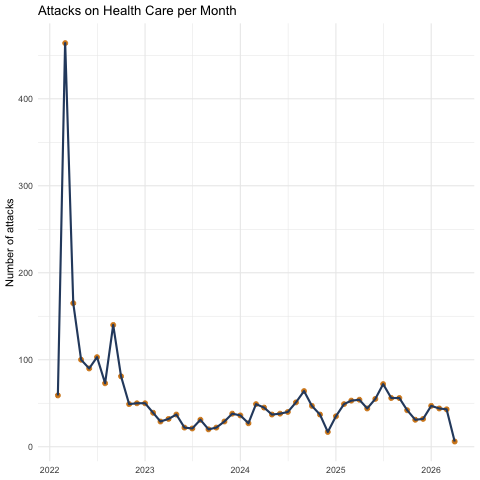

In [19]:
%%R -i attacks_per_month

ggplot(attacks_per_month, aes(x = Date, y = count)) +
  geom_point(color = "#D4861A", size = 2) +
  geom_line(color = "#2C4A6E", linewidth = 1) +
  theme_minimal() +
  labs(
    title = "Attacks on Health Care per Month",
    x = NULL,
    y = "Number of attacks"
  )

In [20]:
%%R 
# Saving the plot as an SVG for further editing in Adobe Illustrator
ggsave("attacks_per_month.svg")

Saving 6.67 x 6.67 in image


According to the WHO, the number of attacks on healthcare in Ukraine increased by 20% in 2025 compared to the previous year. This trend is the main focus of this project.

Source: https://www.who.int/news/item/23-02-2026-attacks-on-ukraine-s-health-care-increased-by-20-in-2025

In order to verify this information, I ran the code below.

In [12]:
# Number of attacks per year
df["Year"] = pd.to_datetime(df["ATTACKDATE"], format="%d/%m/%y").dt.to_period('Y')
df["Year"].value_counts()

Year
2022    1374
2025     579
2024     488
2023     370
2026     140
Freq: Y-DEC, Name: count, dtype: int64

In [ ]:
# Based on my calculations, the increase equals 18.6%. The WHO article title states 20%, but the article itself clarifies the figure as "nearly 20%".

((579 - 488)/ 488) * 100

18.647540983606557

Another part of the dataset that I meant to explore was the WHO classification of attacks. I was inspired by The New York Times article "Visualizing the $13.6 Billion in U.S. Spending on Ukraine" and their treemap breaking down different types of spending.

NYT article: https://www.nytimes.com/interactive/2022/03/18/upshot/ukraine-aid-details.html

In [14]:
# I started by exploring different types of attacks, which showed that attacks are often classified under multiple categories simultaneously

print(df["ATTACKTYPE"].value_counts())

ATTACKTYPE
 Violence with heavy weapons (requires more than one person to use such as firearms, tanks, missiles, bombs, mortars)                                                                                                                                                                                                                                                                                                                2578
 Removal of health care assets (e.g. transport, supplies, materials)                                                                                                                                                                                                                                                                                                                                                                  117
 Removal of health care assets (e.g. transport, supplies, materials), Violence with heavy weapons (requires more than one person to use s

In [ ]:
# Looking at the output above, we can deduce that different types are separated by a comma and their descriptions start with a capital letter. 
# This is the perfect use case for a regular expression, which can describe this rule. 
# I asked Claude for a function to split the cell contents, and it suggested using .explode. The method unpacks each list so every attack type becomes its own row.
# str.strip() helped to account for any leftover whitespace around each value. Without it some of the categories were incorrectly treated as separate. 

attack_counts = df["ATTACKTYPE"].apply(lambda x: re.split(r',\s*(?=[A-Z])', x)).explode().str.strip().value_counts().reset_index()
attack_counts.columns = ["attack_type", "count"]
attack_counts

,attack_type,count
0,Violence with heavy weapons (requires more tha...,2655
1,"Removal of health care assets (e.g. transport,...",225
2,Militarization of a health care asset,103
3,"Violence with individual weapons (knives, bric...",70
4,Psychological violence/threat of violence/inti...,60
5,Obstruction to health care delivery (e.g. phys...,56
6,Unknown,40
7,Armed or violent search of health care personn...,19
8,Abduction/Arrest/Detention of health personnel...,19
9,Assault (without weapons),4


In addition: Warning message:
In geom_treemap_text(colour = "white", place = "topleft", fontface = "bold",  :
  Ignoring unknown parameters: `overflow`


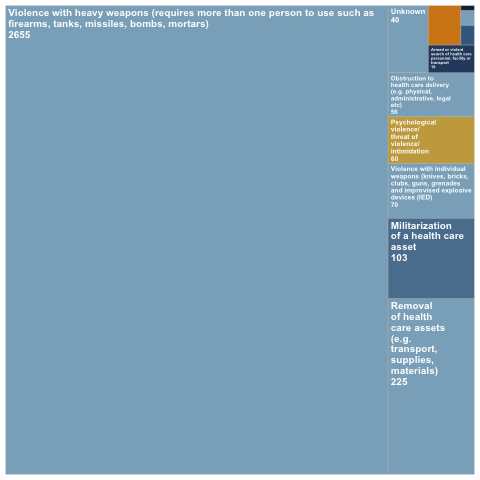

In [21]:
%%R -i attack_counts

# Treemap with attack types count

ggplot(attack_counts, aes(
    area = count,
    fill = attack_type,
    label = paste(attack_type, count, sep = "\n")
  )) +
  geom_treemap() +
  geom_treemap_text(
    colour = "white",
    place = "topleft",
    fontface = "bold",
    size = 10,
    grow = FALSE,
    reflow = TRUE,
    overflow = "hide"
  ) +
  scale_fill_manual(values = c(
    "#D4861A", "#2C4A6E", "#3D6B8E",
    "#5A7F9E", "#8AAFC4", "#1C2B3A",
    "#C9A84C", "#8AAFC4", "#8AAFC4", 
    "#8AAFC4", "#8AAFC4", "#8AAFC4"
  )) +
  theme(legend.position = "none")

In [22]:
%%R 
# Saving the plot as an SVG for further editing in Adobe Illustrator
ggsave("attacks_types_treemap.svg")

Saving 6.67 x 6.67 in image
